## **TASK 2**

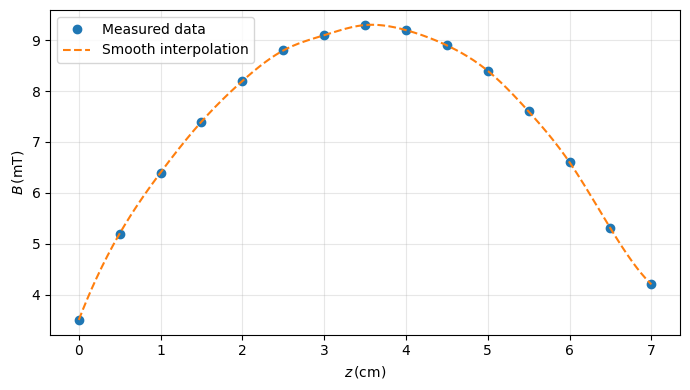

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# --- Data (Task 2): axial field profile at I_eff = 1.0 A ---
z = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5,
              4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0])  # [cm]
B = np.array([3.5, 5.2, 6.4, 7.4, 8.2, 8.8, 9.1, 9.3,
              9.2, 8.9, 8.4, 7.6, 6.6, 5.3, 4.2])  # [mT]

# --- Smooth interpolation curve through the data points ---
z_smooth = np.linspace(z.min(), z.max(), 400)
spline = make_interp_spline(z, B, k=3)   # cubic spline interpolation
B_smooth = spline(z_smooth)

# --- Plot ---
plt.figure(figsize=(7, 4))
plt.plot(z, B, "o", label="Measured data")
plt.plot(z_smooth, B_smooth, "--", label="Smooth interpolation")

plt.xlabel(r"$z\,(\mathrm{cm})$")
plt.ylabel(r"$B\,(\mathrm{mT})$")
plt.grid(alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()

# --- Save figure ---
outpath = "../resources/figures/B_z.png"
plt.savefig(outpath, dpi=300)
plt.show()

## **TASK 3**

Conversion factor B_avg / B_center = 0.8011
m = 7.9306 ± 0.0308 mT/A
b = -0.4878 ± 0.0294 mT


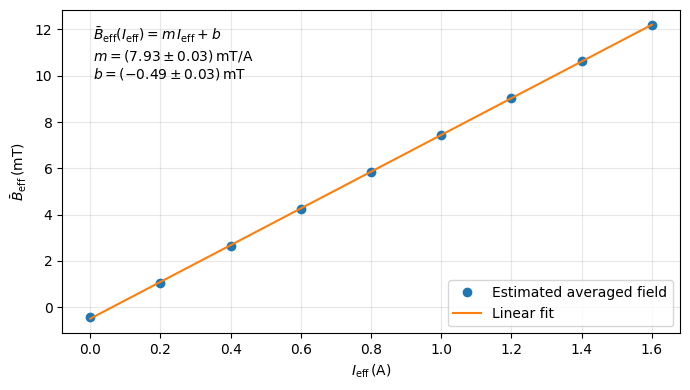

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# --- Data (Task 3): measured center field at z = 3.5 cm ---
I_eff = np.array([0.00, 0.20, 0.40, 0.60, 0.80, 1.00, 1.20, 1.40, 1.60])  # [A]
B_center = np.array([-0.5,  1.3,  3.3,  5.3,  7.3,  9.3, 11.3, 13.3, 15.2])  # [mT]

# --- Conversion from center field to length-averaged field ---
# From Task 2 at I_eff = 1.0 A:
# B_avg_eff = 7.45 mT, B_center = 9.3 mT
conversion_factor = 7.45 / 9.3   # ≈ 0.8011

B_avg = conversion_factor * B_center

print(f"Conversion factor B_avg / B_center = {conversion_factor:.4f}")

# --- Linear regression: B_avg = m*I + b ---
(coefs, cov) = np.polyfit(I_eff, B_avg, deg=1, cov=True)
m, b = coefs
sigma_m = np.sqrt(cov[0, 0])
sigma_b = np.sqrt(cov[1, 1])

print(f"m = {m:.4f} ± {sigma_m:.4f} mT/A")
print(f"b = {b:.4f} ± {sigma_b:.4f} mT")

# --- Plot ---
I_plot = np.linspace(I_eff.min(), I_eff.max(), 200)
B_fit = m * I_plot + b

plt.figure(figsize=(7, 4))
plt.plot(I_eff, B_avg, "o", label="Estimated averaged field")
plt.plot(I_plot, B_fit, "-", label="Linear fit")

# Put fit results into the plot
fit_text = (
    r"$\bar B_{\mathrm{eff}}(I_{\mathrm{eff}})=m\,I_{\mathrm{eff}}+b$" "\n"
    rf"$m=({m:.2f}\pm{sigma_m:.2f})\,\mathrm{{mT/A}}$" "\n"
    rf"$b=({b:.2f}\pm{sigma_b:.2f})\,\mathrm{{mT}}$" "\n"
)
plt.text(
    0.05, 0.95, fit_text,
    transform=plt.gca().transAxes,
    va="top"
)

plt.xlabel(r"$I_{\mathrm{eff}}\,(\mathrm{A})$")
plt.ylabel(r"$\bar B_{\mathrm{eff}}\,(\mathrm{mT})$")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# --- Save figure ---
outpath = "../resources/figures/Bcenter_calibration_fit.png"
plt.savefig(outpath, dpi=300)
plt.show()